# Image Segmentation Problem

Required to propose a solution for the binary image segmentation task, using the example of predicting masks for road signs or pedestrian crosswalks in photographs.

**Requirement:** The mean IoU (Intersection over Union) metric on the test portion of the dataset must be at least 0.65.

Tasks:

1. Prepare the dataset and dataloaders, ensuring that normalization and transformations have been applied successfully.
2. Define the model architecture.
3. Implement a training function that displays six images (input images, predicted masks, and ground-truth masks) after each epoch. Implement model checkpoint saving during training. Implement cells that allow loading a pre-trained model (without creating a new one), evaluating its performance, and continuing training.
4. Train the model, plot the metric and loss curves, analyze them, and draw conclusions.
5. Visualize the results on the test dataset: display 6 random images (image indices must not be hardcoded), along with their predicted masks, ground-truth masks, and the IoU score for each image.
6. Add data augmentation to the training dataset. Perform a test output of 6 samples from the dataloader.
7. Train a new model (the same architecture as before, just a new instance) on the augmented data.
8. Compare the training results on the original dataset versus the augmented dataset.

## Environment setup

Import required modules.

In [ ]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
from torch import optim

from torchvision import models, transforms
from torchsummary import summary

import time
import math
import random

from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import accuracy_score

import seaborn as sns
from matplotlib import colors, pyplot as plt
from matplotlib import rcParams
from IPython.display import clear_output

from tqdm import tqdm

%matplotlib inline
rcParams['figure.figsize'] = (15,4)
sns.set(style="darkgrid", font_scale=1.4)

For reproducibility of the results, fix seed parameter in random number generators.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

The GPU can be used to accelerate training. For convenience, let's create a special variable.

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

CPU = torch.device('cpu')

In [ ]:
#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')

Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


<ipython-input-4-479eaf52c20e>:6: FutureWarning: `torch.cuda.memory_cached` has been renamed to `torch.cuda.memory_reserved`
  print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')


## Dataset loading

In [ ]:
!gdown 1y0DFYBiarGN_mQx6IjI7JF9xYpoXlnJO

Downloading...
From (original): https://drive.google.com/uc?id=1y0DFYBiarGN_mQx6IjI7JF9xYpoXlnJO
From (redirected): https://drive.google.com/uc?id=1y0DFYBiarGN_mQx6IjI7JF9xYpoXlnJO&confirm=t&uuid=66c37491-cf2c-4ab5-b9e1-c36360644f03
To: /kaggle/working/segmentation.zip
100%|████████████████████████████████████████| 419M/419M [00:06<00:00, 68.5MB/s]


In [ ]:
!ls

segmentation.zip


In [ ]:
#from google.colab import drive
#drive.mount('/content/gdrive/')

In [ ]:
#!ls /content/gdrive/MyDrive/University/MLR


In [ ]:
!unzip -q segmentation.zip

## Data preparation

Let's take a look at the dataset of road photos and prepare it for training if necessary.

In [ ]:
X = np.load('./x_train.npy')
Y = np.load('./y_train.npy')

print(X.shape)
print(Y.shape)

(3083, 256, 256, 3)
(3083, 256, 256, 1)


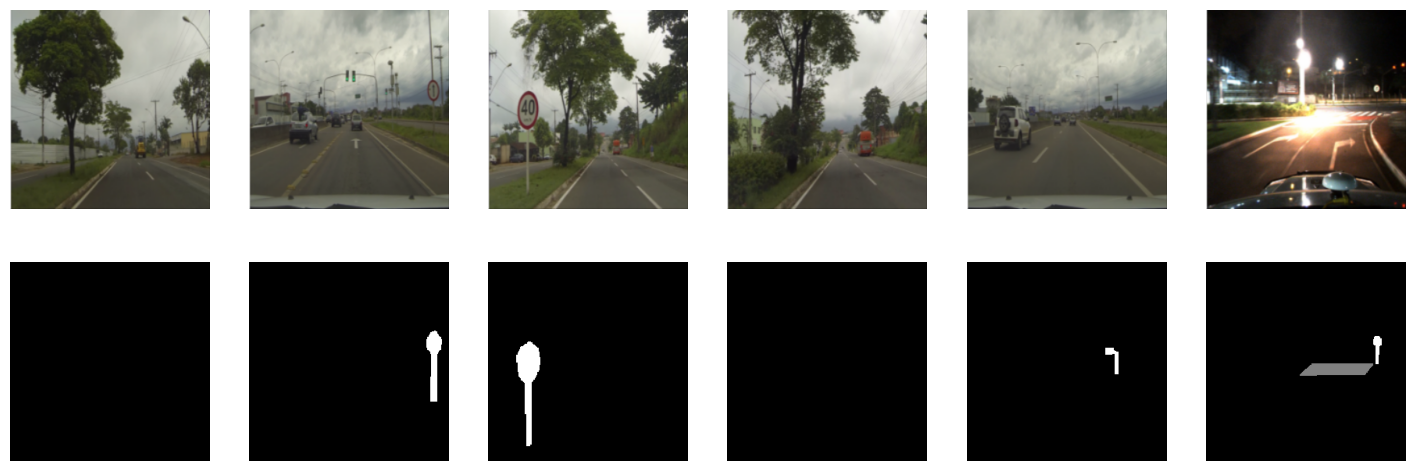

In [ ]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 100+i*10;
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[j])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[j].squeeze(), cmap='gray')
plt.show();

In [ ]:
XX = np.transpose(X[0:3000:3], axes=(0, 3, 1, 2))
YY = np.transpose(Y[0:3000:3], axes=(0, 3, 1, 2))

print(XX.shape)
print(YY.shape)

(1000, 3, 256, 256)
(1000, 1, 256, 256)


Let's check the targets in the mask

In [ ]:
unique, counts = np.unique(YY, return_counts=True)
print(unique, counts)

[0 1 2] [62570586  2697615   267799]


So we have

*   0 – background
*   1 – road sign
*   2 – crosswalk

The task is binary segmentation so we'll make target equal to 1 on every pixel of road sign AND crosswalk


In [ ]:
YY = np.clip(YY, a_min=0, a_max=1)

Now let's check the targets again. Number of zeros must stay the same and the number of ones must become the sum of ones and twos before

In [ ]:
unique, counts = np.unique(YY, return_counts=True)
print(unique, counts)

[0 1] [62570586  2965414]


Normalizing

In [ ]:
XXX = np.array(XX / 255, dtype='float32')
YYY = np.array(YY, dtype='float32')

print(XXX.shape)
print(YYY.shape)

(1000, 3, 256, 256)
(1000, 1, 256, 256)


In [ ]:
X_t = torch.FloatTensor(XXX)
Y_t = torch.FloatTensor(YYY)

for x in X_t:
  transforms.functional.normalize(x, (0.485, 0.456, 0.406), (0.229, 0.224, 0.225), inplace=True)

print(X_t.shape)
print(X_t[0])

torch.Size([1000, 3, 256, 256])
tensor([[[ 1.5297,  1.0673,  0.9474,  ...,  1.2385,  1.1872,  0.8618],
         [ 1.8379,  1.3242,  1.1872,  ...,  1.4783,  1.4440,  1.1700],
         [ 1.8379,  1.3242,  1.1872,  ...,  1.4612,  1.4783,  1.2214],
         ...,
         [ 1.8379, -0.2171, -1.1075,  ..., -1.0219, -1.0390, -1.1418],
         [ 1.8379, -0.2171, -1.1247,  ..., -1.0562, -1.0733, -1.1760],
         [ 1.5297, -0.4054, -1.2788,  ..., -1.2445, -1.2445, -1.3302]],

        [[ 1.6933,  1.2556,  1.1506,  ...,  1.4482,  1.3957,  1.0455],
         [ 2.0084,  1.5357,  1.4132,  ...,  1.6933,  1.6583,  1.3782],
         [ 2.0084,  1.5357,  1.4132,  ...,  1.6758,  1.6933,  1.4132],
         ...,
         [ 2.0084, -0.0749, -0.9678,  ..., -0.9328, -0.9503, -1.0553],
         [ 2.0084, -0.0749, -0.9853,  ..., -0.9678, -0.9853, -1.0903],
         [ 1.6933, -0.2850, -1.1604,  ..., -1.1604, -1.1604, -1.2479]],

        [[ 1.9080,  1.4200,  1.2980,  ...,  1.5594,  1.4897,  1.1585],
         [ 2.

Splitting the dataset to test val and train

In [ ]:
ix = np.random.choice(len(XX), len(XX), False)
tr, val, ts = np.split(ix, [700, 850])

In [ ]:
print(len(tr), len(val), len(ts))

700 150 150


Create dataloaders

In [ ]:
X_train_t = X_t[tr]
Y_train_t = Y_t[tr]
X_val_t = X_t[val]
Y_val_t = Y_t[val]
X_test_t = X_t[ts]
Y_test_t = Y_t[ts]

train_dataset = TensorDataset(X_train_t, Y_train_t)
val_dataset = TensorDataset(X_val_t, Y_val_t)
test_dataset = TensorDataset(X_test_t, Y_test_t)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
loaders = {
    'train': train_dataloader,
    'valid': val_dataloader
}

Next we have function to show normalized tensor images 

In [ ]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

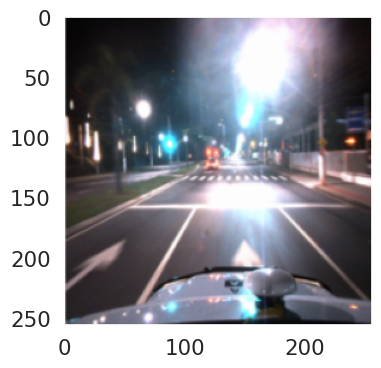

In [ ]:
imshow((next(iter(train_dataloader)))[0][0])

## Model initialization

Defining SegNet and UNet architecture

In [ ]:
class SegNet(nn.Module):
  def __init__(self, n_class):
    super().__init__()
    self.n_class = n_class

    self.enc_conv0 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU()
    )
    self.pool0 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)


    self.enc_conv1 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU()
    )
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)


    self.enc_conv2 = nn.Sequential(
        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU()
    )
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)


    self.enc_conv3 = nn.Sequential(
        nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU()
    )
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)


    self.enc_conv4 = nn.Sequential(
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU()
    )
    self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)


    self.unpool0 = nn.MaxUnpool2d(kernel_size=2, stride=2)
    self.dec_conv0 = nn.Sequential(
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU()
    )


    self.unpool1 = nn.MaxUnpool2d(kernel_size=2, stride=2)
    self.dec_conv1 = nn.Sequential(
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.Conv2d(in_channels=512, out_channels=256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU()
    )


    self.unpool2 = nn.MaxUnpool2d(kernel_size=2, stride=2)
    self.dec_conv2 = nn.Sequential(
        nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU()
    )


    self.unpool3 = nn.MaxUnpool2d(kernel_size=2, stride=2)
    self.dec_conv3 = nn.Sequential(
        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
    )


    self.unpool4 = nn.MaxUnpool2d(kernel_size=2, stride=2)
    self.dec_conv4 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Conv2d(in_channels=64, out_channels=n_class, kernel_size=3, padding=1)
    )

  def forward(self, x):
    x, ind0 = self.pool0(self.enc_conv0(x))
    x, ind1 = self.pool1(self.enc_conv1(x))
    x, ind2 = self.pool2(self.enc_conv2(x))
    x, ind3 = self.pool3(self.enc_conv3(x))
    x, ind4 = self.pool4(self.enc_conv4(x))

    x = self.dec_conv0(self.unpool0(x, ind4))
    x = self.dec_conv1(self.unpool1(x, ind3))
    x = self.dec_conv2(self.unpool2(x, ind2))
    x = self.dec_conv3(self.unpool3(x, ind1))
    x = self.dec_conv4(self.unpool4(x, ind0))

    return x

In [ ]:
class UNet(nn.Module):
  def __init__(self, in_channels=3, out_channels=1, init_features=64):
    super().__init__()

    features = init_features
    self.encoder1 = nn.Sequential(
        nn.Conv2d(in_channels=in_channels, out_channels=features, kernel_size=3, padding=1),
        nn.BatchNorm2d(features),
        nn.ReLU(),
        nn.Conv2d(in_channels=features, out_channels=features, kernel_size=3, padding=1),
        nn.BatchNorm2d(features),
        nn.ReLU()
    )
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)


    self.encoder2 = nn.Sequential(
        nn.Conv2d(in_channels=features, out_channels=2*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(2*features),
        nn.ReLU(),
        nn.Conv2d(in_channels=2*features, out_channels=2*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(2*features),
        nn.ReLU()
    )
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


    self.encoder3 = nn.Sequential(
        nn.Conv2d(in_channels=2*features, out_channels=4*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(4*features),
        nn.ReLU(),
        nn.Conv2d(in_channels=4*features, out_channels=4*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(4*features),
        nn.ReLU()
    )
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)


    self.encoder4 = nn.Sequential(
        nn.Conv2d(in_channels=4*features, out_channels=8*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(8*features),
        nn.ReLU(),
        nn.Conv2d(in_channels=8*features, out_channels=8*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(8*features),
        nn.ReLU()
    )
    self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)


    self.bottleneck = nn.Sequential(
        nn.Conv2d(in_channels=8*features, out_channels=16*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(16*features),
        nn.ReLU(),
        nn.Conv2d(in_channels=16*features, out_channels=16*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(16*features),
        nn.ReLU()
    )


    self.upconv1 = nn.ConvTranspose2d(in_channels=16*features, out_channels=8*features, kernel_size=2, stride=2)
    self.decoder1 = nn.Sequential(
        nn.Conv2d(in_channels=2*8*features, out_channels=8*features, kernel_size=3, padding=1), # in_channels times 2 because of concatenation
        nn.BatchNorm2d(8*features),
        nn.ReLU(),
        nn.Conv2d(in_channels=8*features, out_channels=8*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(8*features),
        nn.ReLU()
    )


    self.upconv2 = nn.ConvTranspose2d(in_channels=8*features, out_channels=4*features, kernel_size=2, stride=2)
    self.decoder2 = nn.Sequential(
        nn.Conv2d(in_channels=2*4*features, out_channels=4*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(4*features),
        nn.ReLU(),
        nn.Conv2d(in_channels=4*features, out_channels=4*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(4*features),
        nn.ReLU()
    )


    self.upconv3 = nn.ConvTranspose2d(in_channels=4*features, out_channels=2*features, kernel_size=2, stride=2)
    self.decoder3 = nn.Sequential(
        nn.Conv2d(in_channels=2*2*features, out_channels=2*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(2*features),
        nn.ReLU(),
        nn.Conv2d(in_channels=2*features, out_channels=2*features, kernel_size=3, padding=1),
        nn.BatchNorm2d(2*features),
        nn.ReLU()
    )


    self.upconv4 = nn.ConvTranspose2d(in_channels=2*features, out_channels=features, kernel_size=2, stride=2)
    self.decoder4 = nn.Sequential(
        nn.Conv2d(in_channels=2*features, out_channels=features, kernel_size=3, padding=1),
        nn.BatchNorm2d(features),
        nn.ReLU(),
        nn.Conv2d(in_channels=features, out_channels=features, kernel_size=3, padding=1),
        nn.BatchNorm2d(features),
        nn.ReLU()
    )

    self.conv1x1 = nn.Conv2d(in_channels=features, out_channels=out_channels, kernel_size=1)

  def forward(self, x):
      enc1 = self.encoder1(x)
      enc2 = self.encoder2(self.pool1(enc1))
      enc3 = self.encoder3(self.pool2(enc2))
      enc4 = self.encoder4(self.pool3(enc3))

      bottleneck = self.bottleneck(self.pool4(enc4))

      dec1 = self.upconv1(bottleneck)
      dec1 = torch.cat((dec1, enc4), dim=1)
      dec1 = self.decoder1(dec1)

      dec2 = self.upconv2(dec1)
      dec2 = torch.cat((dec2, enc3), dim=1)
      dec2 = self.decoder2(dec2)

      dec3 = self.upconv3(dec2)
      dec3 = torch.cat((dec3, enc2), dim=1)
      dec3 = self.decoder3(dec3)

      dec4 = self.upconv4(dec3)
      dec4 = torch.cat((dec4, enc1), dim=1)
      dec4 = self.decoder4(dec4)

      return self.conv1x1(dec4)

## Metric

As a metric, we will use the Intersection over Union (IoU) — the ratio of the intersection of the masks to their union

By definition, the metric is calculated using the following formula:
$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$



In [ ]:
def iou_pytorch(outputs: torch.Tensor, labels: torch.Tensor):
    outputs = outputs.squeeze(1).byte()  # BATCH x 1 x H x W => BATCH x H x W
    labels = labels.squeeze(1).byte()
    SMOOTH = 1e-8 # small positive number to avoid division by zero

    intersection = (outputs & labels).sum((1, 2))
    union = (outputs | labels).sum((1, 2))

    iou = (intersection + SMOOTH)/(union + SMOOTH)

    return iou

Check if the function is correct

In [ ]:
outputs = torch.FloatTensor([[[1., 0.], [0., 1.]], [[1., 0.], [0., 1.]]])
oposite = torch.FloatTensor([[[0., 1.], [1., 0.]], [[0., 1.], [1., 0.]]])
intersected = torch.FloatTensor([[[1., 1.], [0., 1.]], [[1., 1.], [0., 1.]]])

print('iou_pytorch(outputs, outputs)', iou_pytorch(outputs, outputs).mean().item())
print('iou_pytorch(oposite, oposite)', iou_pytorch(oposite, oposite).mean().item())
print('iou_pytorch(intersected, intersected)', iou_pytorch(intersected, intersected).mean().item())

print('iou_pytorch(outputs, oposite)', iou_pytorch(outputs, oposite).mean().item())
print('iou_pytorch(outputs, intersected)', iou_pytorch(outputs, intersected).mean().item())
print('iou_pytorch(oposite, intersected)', iou_pytorch(oposite, intersected).mean().item())

iou_pytorch(outputs, outputs) 1.0
iou_pytorch(oposite, oposite) 1.0
iou_pytorch(intersected, intersected) 1.0
iou_pytorch(outputs, oposite) 2.4999999848063226e-09
iou_pytorch(outputs, intersected) 0.6666666865348816
iou_pytorch(oposite, intersected) 0.25


## Training function

In [ ]:
def plot_example(X_batch, Y_batch, Y_pred, title):
    clear_output(wait=True)

    plt.rcParams['figure.figsize'] = (15, 8)
    for k in range(6):
      plt.subplot(3, 6, k+1)
      imshow(X_batch[k])
      plt.title('Photo')
      plt.axis('off')

      if Y_batch != None:
        plt.subplot(3, 6, k+7)
        plt.imshow(Y_batch[k, 0], cmap='gray')
        plt.title('Mask')
        plt.axis('off')

      if Y_pred != None:
        plt.subplot(3, 6, k+13)
        plt.imshow(Y_pred[k, 0], cmap='gray')
        plt.title('Pred')
        plt.axis('off')

    plt.suptitle(title)
    plt.show()

In [ ]:
def train(name, model, optimizer, loss_fn, metric_fn, epochs, loaders):
    losses = {"train": [], "valid": []}
    scores = {"train": [], "valid": []}

    best_val_loss = float('inf')
    best_val_iou = 0

    for epoch in range(epochs):
        print('* Epoch %d/%d' % (epoch+1, epochs))

        for stage, dataloader in loaders.items():
            avg_loss = 0
            avg_score = 0

            if stage == 'train':
                model.train()
            else:
                model.eval()

            for _, (X_batch, Y_batch) in tqdm(enumerate(dataloader),
                                              total=len(dataloader)):
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                if stage == 'train':
                    optimizer.zero_grad()

                    logits = model(X_batch)
                    loss = loss_fn(logits, Y_batch)

                    loss.backward()
                    optimizer.step()

                else:
                    with torch.no_grad():
                        # code to predict logits and calc losses
                        logits = model(X_batch)
                        loss = loss_fn(logits, Y_batch)
                        val_loss = loss


                # calculate score and loss to show
                Y_pred = torch.round(torch.sigmoid(logits.detach()))
                score = metric_fn(Y_pred.cpu(), Y_batch.cpu()).mean().item()

                avg_loss += loss.detach().cpu().numpy() / len(dataloader)
                avg_score += score / len(dataloader)

                #scheduler.step(avg_loss)

                # clean GPU memory
                X_batch = X_batch.cpu()
                Y_batch = Y_batch.cpu()
                logits = logits.cpu()
                Y_pred = Y_pred.cpu()
                torch.cuda.empty_cache()

            losses[stage].append(avg_loss)
            scores[stage].append(avg_score)

        if stage == 'valid':
            # add code to show intermediate results
            plot_example(X_batch, Y_batch, Y_pred, f"Epoch {epoch+1}/{epochs}, avg_loss = {avg_loss}, avg_score = {avg_score}")

            # if val_loss < best_val_loss:
            #   best_val_loss = val_loss
            #   torch.save(model.state_dict(), f'{name}_epoch_{epoch+1}_best_val_loss.pt')

            if avg_score > best_val_iou:
              best_val_iou = avg_score
              torch.save(model.state_dict(), f'{name}_epoch_{epoch+1}_best_val_iou.pt')

    return losses, scores

## Training

In [ ]:
segnet = SegNet(1).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(segnet.parameters(), lr=1e-4)

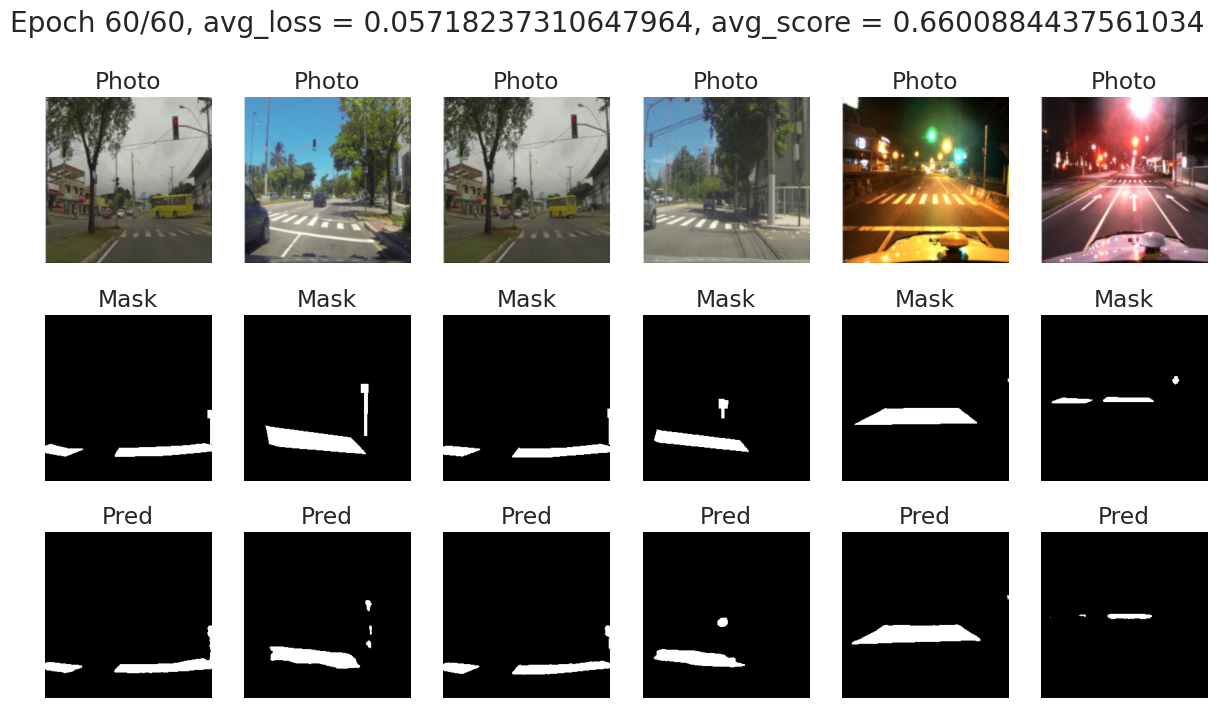

In [ ]:
losses_segnet, scores_segnet = train('segnet', segnet, optimizer, loss_fn, iou_pytorch, 60, loaders)

In [ ]:
unet = UNet().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_unet = optim.Adam(unet.parameters(), lr=1e-4)

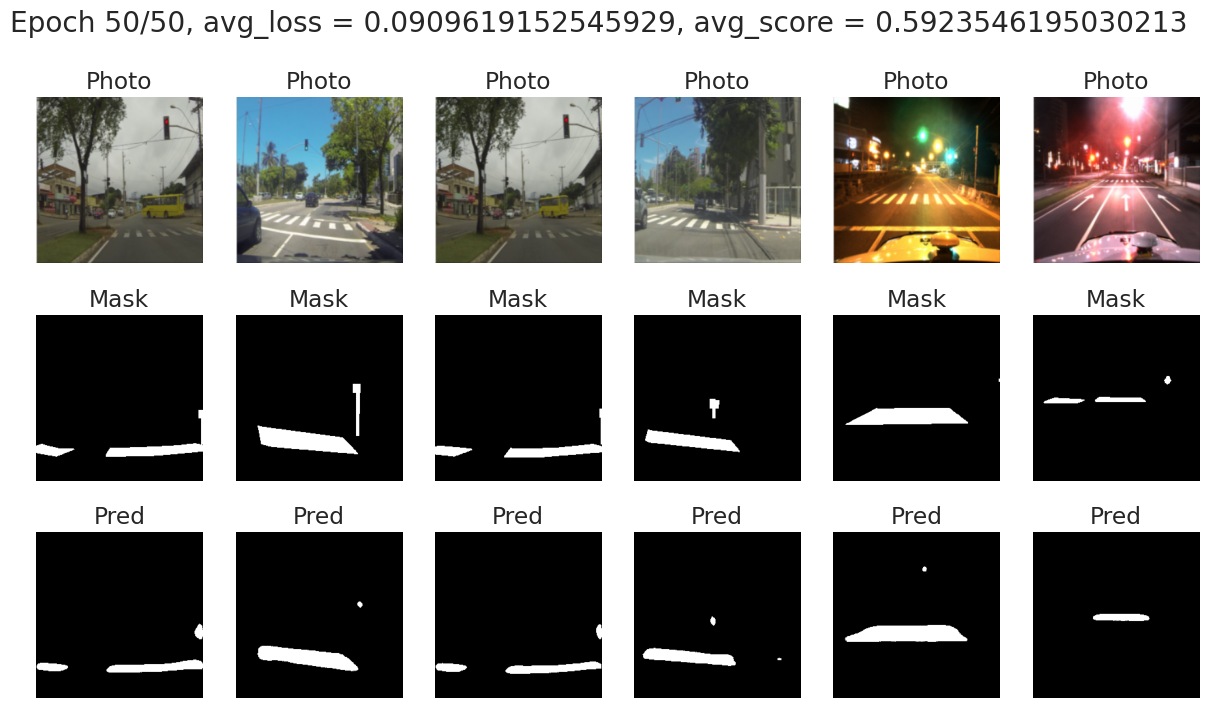

In [ ]:
losses_unet, scores_unet = train('unet', unet, optimizer_unet, loss_fn, iou_pytorch, 50, loaders)

Let's look at the metric and loss curves

In [ ]:
def plot_losses_scores(losses, scores):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))


  ax1.plot(range(len(losses['train'])), losses['train'], label='train loss')
  ax1.plot(range(len(losses['valid'])), losses['valid'], label='valid loss')
  ax2.plot(range(len(scores['valid'])), scores['valid'], label = f'val iou')
  ax1.set_title("Loss")
  ax2.set_title("IoU")
  ax1.legend()
  plt.show()

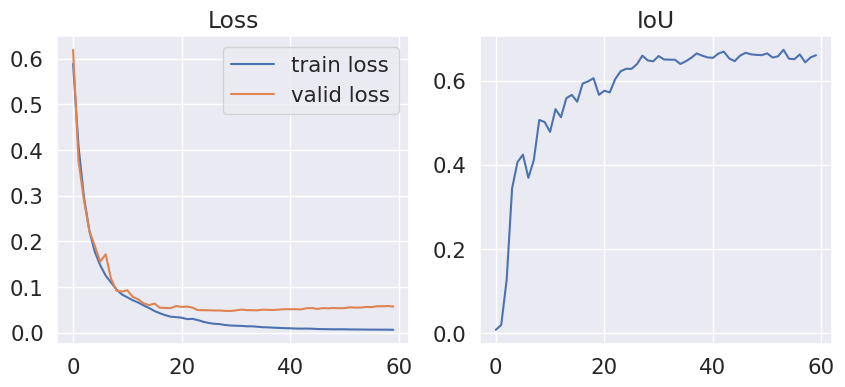

In [ ]:
plot_losses_scores(losses_segnet, scores_segnet)

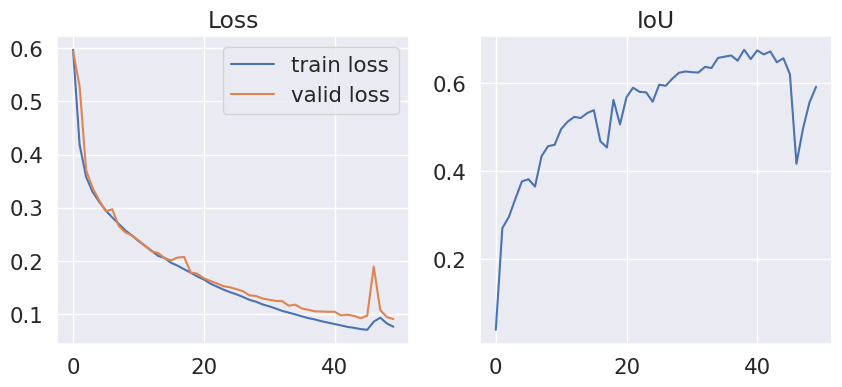

In [ ]:
plot_losses_scores(losses_unet, scores_unet)

In [ ]:
def predict_eval_on_batch(model, X_batch, device=device):
  model.eval()
  model.to(device)

  with torch.no_grad():
    if X_batch.device != device:
      X_batch = X_batch.to(device)

    logits = model(X_batch).detach()
    Y_pred = torch.round(torch.sigmoid(logits))

    if device != CPU:
      X_batch = X_batch.cpu()
      Y_pred = Y_pred.cpu()
      logits = logits.cpu()

  return Y_pred, logits

In [ ]:
def predict(model, dataloader, device=device):
  Y_preds = []

  for X_batch, _ in dataloader:
    Y_pred, logits = predict_eval_on_batch(model, X_batch, device=device)
    Y_preds.append(Y_pred)

  return np.array(torch.cat(Y_preds))

In [ ]:
def score_model(model, metric, dataloader, device=device):
  score=0
  for X_batch, Y_label in dataloader:
    Y_pred, _ = predict_eval_on_batch(model, X_batch, device)
    score += metric(Y_pred, Y_label).mean().item() / len(dataloader)

  return score

In [ ]:
def load_model_state(model, ckpt_name):
  if device == CPU:
    return model.load_state_dict(torch.load(f'{ckpt_name}', map_location=torch.device("cpu")))
  else:
    model.load_state_dict(torch.load(f'{ckpt_name}'))

Download best validation models

In [ ]:
!gdown 1Fu1Zc77Y25U5zXR0YAyrDTbUlfrrD0D6
!gdown 1tS17bcjO56dMC7kLbDsExnIqX-AIc5sg

Downloading...
From (original): https://drive.google.com/uc?id=1Fu1Zc77Y25U5zXR0YAyrDTbUlfrrD0D6
From (redirected): https://drive.google.com/uc?id=1Fu1Zc77Y25U5zXR0YAyrDTbUlfrrD0D6&confirm=t&uuid=93a7a7bf-c4d4-4587-8e33-39ec9210e285
To: /kaggle/working/segnet_epoch_54_best_val_iou.pt
100%|████████████████████████████████████████| 118M/118M [00:01<00:00, 88.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1tS17bcjO56dMC7kLbDsExnIqX-AIc5sg
From (redirected): https://drive.google.com/uc?id=1tS17bcjO56dMC7kLbDsExnIqX-AIc5sg&confirm=t&uuid=63c5d08e-c5cc-49d4-8e4a-b85e14d1d6e7
To: /kaggle/working/unet_epoch_39_best_val_iou.pt
100%|████████████████████████████████████████| 124M/124M [00:01<00:00, 65.9MB/s]


In [ ]:
!ls

segmentation.zip		 unet_epoch_39_best_val_iou.pt	y_train.npy
segnet_epoch_54_best_val_iou.pt  x_train.npy


Calculate on test dataset

In [ ]:
load_model_state(segnet, 'segnet_epoch_54_best_val_iou.pt')
score_model(segnet, iou_pytorch, test_dataloader)

<ipython-input-38-65157e8aad54>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'{ckpt_name}'))


0.6729670524597168

In [ ]:
load_model_state(unet, 'unet_epoch_39_best_val_iou.pt')
score_model(unet, iou_pytorch, test_dataloader)

<ipython-input-38-65157e8aad54>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'{ckpt_name}'))


0.676722753047943

## Visualization of results

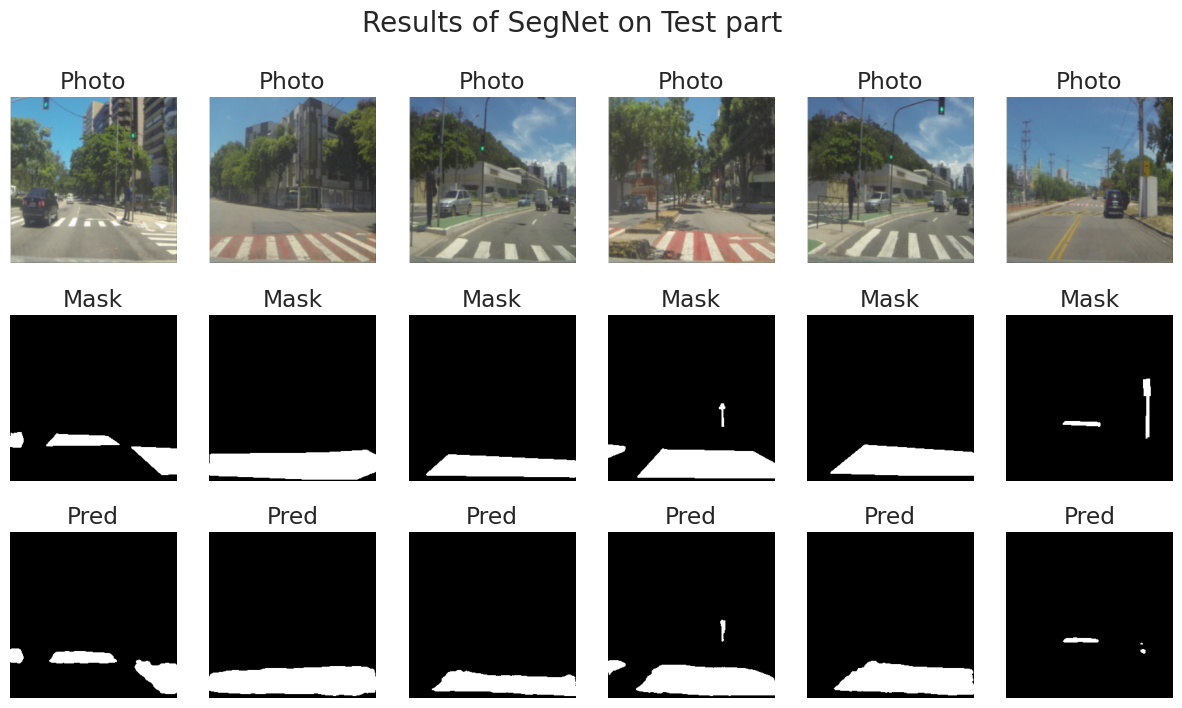

In [ ]:
X_test_batch, Y_test_batch = next(iter(test_dataloader))
Y_test_pred, _ = predict_eval_on_batch(segnet, X_test_batch, device=device)

plot_example(X_test_batch, Y_test_batch, Y_test_pred, 'Results of SegNet on Test part')

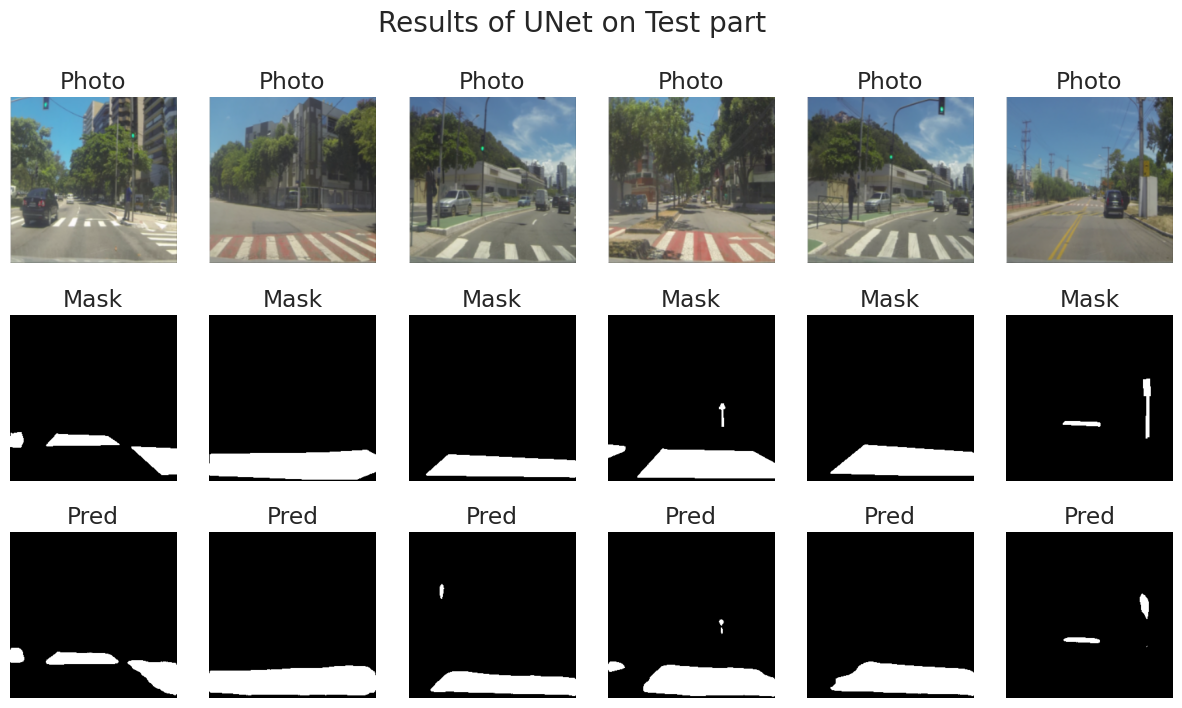

In [ ]:
X_test_batch, Y_test_batch = next(iter(test_dataloader))
Y_test_pred, _ = predict_eval_on_batch(unet, X_test_batch, device=device)

plot_example(X_test_batch, Y_test_batch, Y_test_pred, 'Results of UNet on Test part')

## Data augmentation

In [ ]:
class OurOwnDataset(Dataset):
    def __init__(self, data, masks, transforms=None):
        self.data = data
        self.masks = masks
        self.transforms = transforms

        print(f'Found {len(self.data)} items')

    def __getitem__(self, i):
        image = self.data[i]
        mask = self.masks[i]

        image_mask = torch.cat([image, mask], dim=0)

        if self.transforms:
            image_mask = self.transforms(image_mask)

        return image_mask[:3,:,:], image_mask[3:,:,:]

    def __len__(self):
        return len(self.data)

In [ ]:
from torchvision.transforms.v2 import Compose, RandomHorizontalFlip, RandomPerspective, GaussianBlur

getitem_transforms = Compose([
  RandomHorizontalFlip(p=0.5),
  RandomPerspective(distortion_scale=0.3),
  GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 3.))
])

train_dataset_augmented = OurOwnDataset(X_train_t, Y_train_t, transforms=getitem_transforms)
train_dataloader_augmented = DataLoader(train_dataset_augmented, batch_size=32, shuffle=True)

Found 700 items


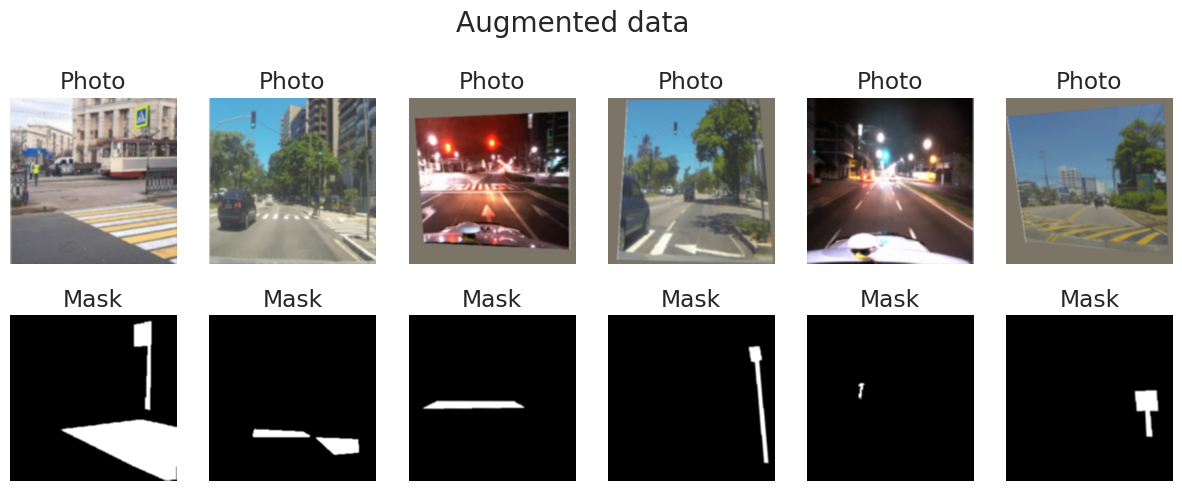

In [ ]:
x, y = next(iter(train_dataloader_augmented))
plot_example(x, y, None, 'Augmented data')

## Training on augmented dataset


We train using augmented data but during validation and testing we use regular datasets

In [ ]:
loaders_augmented = {
    'train': train_dataloader_augmented,
    'valid': val_dataloader
}

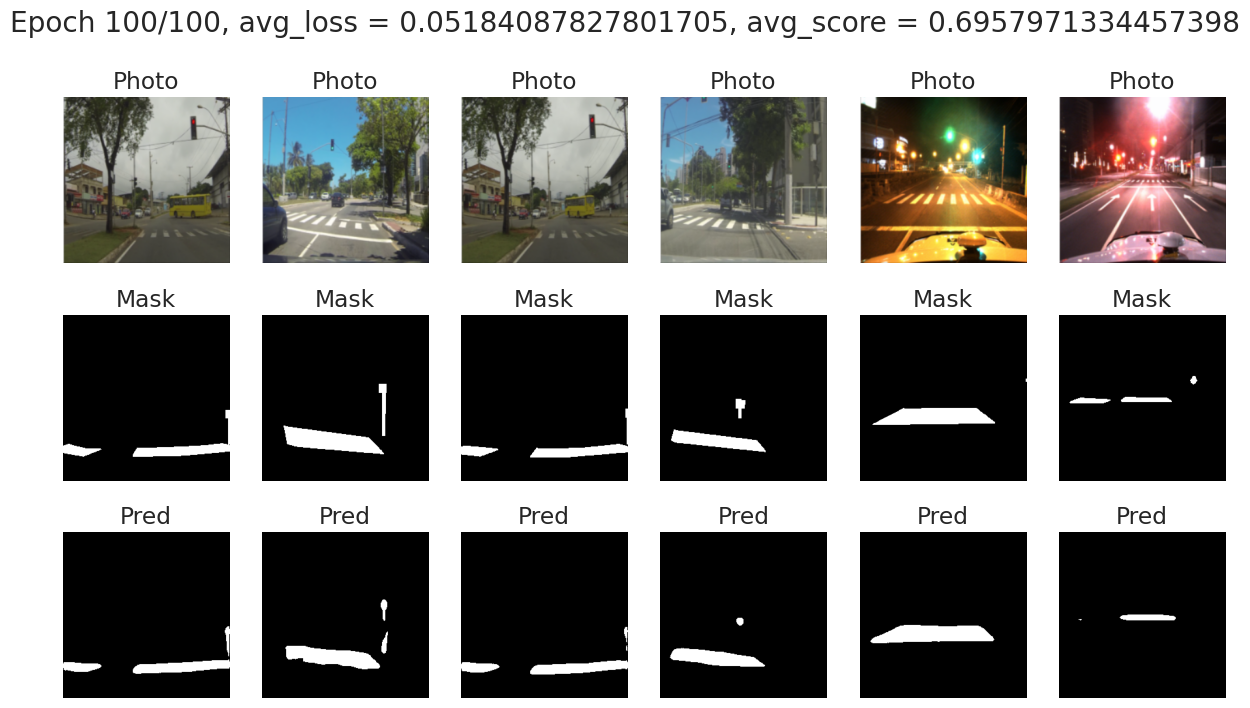

In [ ]:
unet_augmented = UNet().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_unet_augmented = optim.Adam(unet_augmented.parameters(), lr=1e-4)

losses_unet, scores_unet = train('unet_augmented', unet_augmented, optimizer_unet_augmented, loss_fn, iou_pytorch, 100, loaders_augmented)

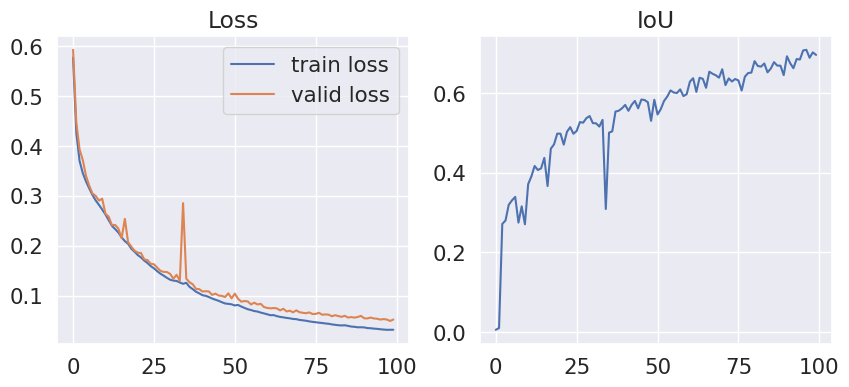

In [ ]:
plot_losses_scores(losses_unet, scores_unet)

As we can see from the validation IoU curve, there is potential for further training, as we haven't yet reached a plateau, but the results are already sufficient for our requirements

## Comparison of trained models

Download best model

In [ ]:
!gdown 1oUEDK2LHCV_WzRrb0440f56ExiAfGeIm

In [ ]:
load_model_state(unet_augmented, 'unet_augmented_epoch_97_best_val_iou.pt')
score_model(unet_augmented, iou_pytorch, test_dataloader)

<ipython-input-38-65157e8aad54>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'{ckpt_name}'))


0.7086612462997436

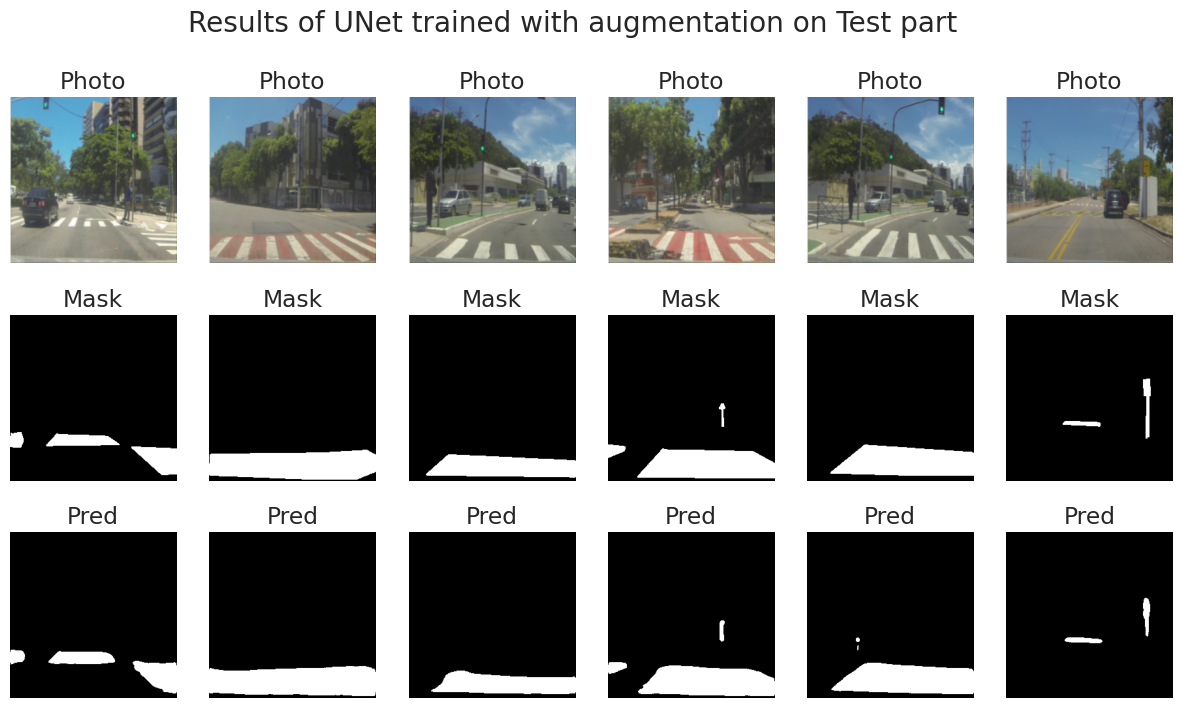

In [ ]:
X_test_batch, Y_test_batch = next(iter(test_dataloader))
Y_test_pred, _ = predict_eval_on_batch(unet_augmented, X_test_batch, device=device)

plot_example(X_test_batch, Y_test_batch, Y_test_pred, 'Results of UNet trained with augmentation on Test part')